In [1]:
import torch
torch.set_float32_matmul_precision("high")
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import matplotlib.pyplot as plt
import shapiq 
import src

### load model

In [2]:
from transformers import AutoProcessor, AutoModel

model = AutoModel.from_pretrained("google/siglip-base-patch16-224")
model.to("cuda")
processor = AutoProcessor.from_pretrained("google/siglip-base-patch16-224")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


### load data

In [3]:
input_text = "black dog next to a yellow hydrant"
# input_image = Image.open("assets/dog_and_hydrant.png")
input_image = Image.open("assets/dog_and_hydrant.png").convert("RGB")


### define game

In [4]:
from ImputerFactory import ImageImputerFactory
from Game.game_huggingface import VisionLanguageGame

factory = ImageImputerFactory()
imputer = factory.build(model, processor, input_image, input_text, segmenter=None, masker="crossmodal_mean")

game = VisionLanguageGame(imputer, batch_size=64)
n_players_image = game.n_players_image
n_players_text = game.n_players_text

### define approximator

In [5]:
fixlip = src.fixlip.FIxLIP(
    n_players_image=n_players_image,
    n_players_text=n_players_text, 
    max_order=2,
    p=0.5, # weight
    mode="banzhaf",
    random_state=0
)

### compute explanation

In [6]:
from src.utils import create_crossmodal_interaction_lookup

crossmodal_lookup = create_crossmodal_interaction_lookup(
    n_players_image=game.n_players_image,
    n_players_text=game.n_players_text,
)

src.utils.set_seed(0)
interaction_values = fixlip.approximate_crossmodal(
    game,
    budget=2**16,
    interaction_lookup=crossmodal_lookup,
)

### visualize explanation

In [7]:
# SigLIP: decode text tokens from the processor's tokenizer
input_ids = game.inputs['input_ids'][0]
tokens = game.processor.tokenizer.convert_ids_to_tokens(input_ids)
# SentencePiece: strip space prefix '▁', keep empty tokens as padding placeholders
text_tokens = [
    t.replace('▁', '') for t, id_ in zip(tokens, input_ids)
    if id_.item() not in (0, 1)
][:game.n_players_text]
assert len(text_tokens) == game.n_players_text

# Denormalize image
input_image_processed = game.inputs['pixel_values'].squeeze(0)
input_image_denormalized = src.utils.denormalize(
    input_image_processed,
    game.processor.image_processor.image_mean,
    game.processor.image_processor.image_std,
).permute(1, 2, 0).numpy()

print("text tokens:", text_tokens)

text tokens: ['black', 'dog', 'next', 'to', '', 'a', 'yellow', '', 'hydr', 'an', 't']


<string>:12: UserWarning: Index FWBII is not a valid index as defined in {'ELC', 'Moebius', 'SGV', 'IGV', 'JointSV', 'STII', 'CHII', 'EGV', 'SII', 'CHGV', 'FBII', 'k-SII', 'kADD-SHAP', 'BII', 'FSII', 'Co-Moebius', 'BGV', 'EC', 'BV', 'SV'}. This might lead to unexpected behavior.


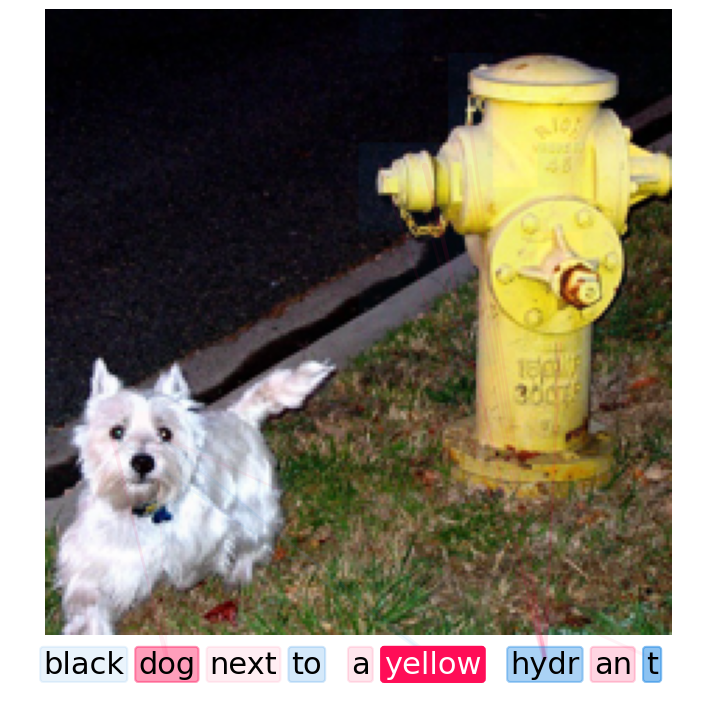

In [8]:
import matplotlib.pyplot as plt

src.plot.plot_image_and_text_together(
    img=input_image_denormalized,
    text=text_tokens,
    image_players=list(range(n_players_image)),
    iv=interaction_values,
    plot_interactions=True,
    top_k=14,
    normalize_jointly=True,
    figsize=(7, 7),
    fontsize=22,
    margin=0.3,
    color_text=True,
    plot_heatmap=True,
    show=False,
)
plt.tight_layout(pad=0.15)